In [41]:
import numpy as np
import matplotlib.pyplot as plt

from functions import (
    simulate_entropy,
    simulate_entropy_with_debt,
    simulate_entropy_proportional,
)

In [42]:
N = 50
M = 1000
steps = 10000
md = 10
gamma = 1 / 3

# Same bin width (0.5) in all three runs so the entropies are comparable.
max_money = 50

t_no_debt, S_no_debt = simulate_entropy(
    N=N, M=M, steps=steps, transaction_type='constant',
    bins=100, max_money=max_money,
)

t_debt, S_debt = simulate_entropy_with_debt(
    N=N, M=M, steps=steps, md=md, transaction_type='constant',
    bins=200, max_money=max_money,
)

t_prop, S_prop = simulate_entropy_proportional(
    N=N, M=M, steps=steps, gamma=gamma,
    bins=100, max_money=max_money,
)

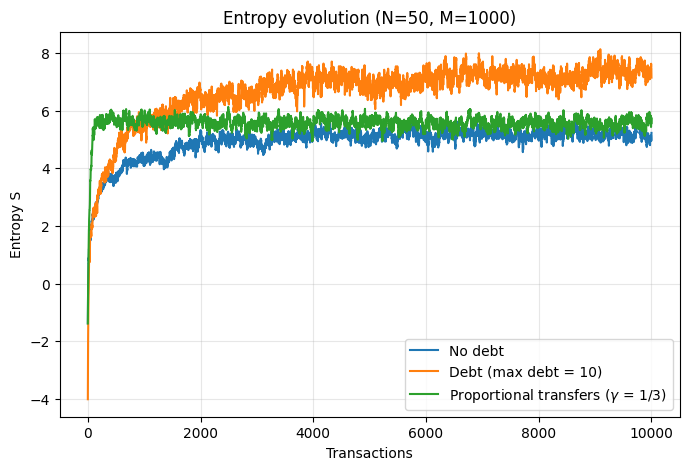

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(t_no_debt, S_no_debt, label='No debt')
plt.plot(t_debt, S_debt, label=f'Debt (max debt = {md})')
plt.plot(t_prop, S_prop, label=f'Proportional transfers ($\\gamma$ = 1/3)')
plt.xlabel('Transactions')
plt.ylabel('Entropy S')
plt.title(f'Entropy evolution (N={N}, M={M})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [44]:
from math import gamma as gamma_fn
from functions import simulate_no_debt, simulate_with_debt, simulate_proportional_money_transfer

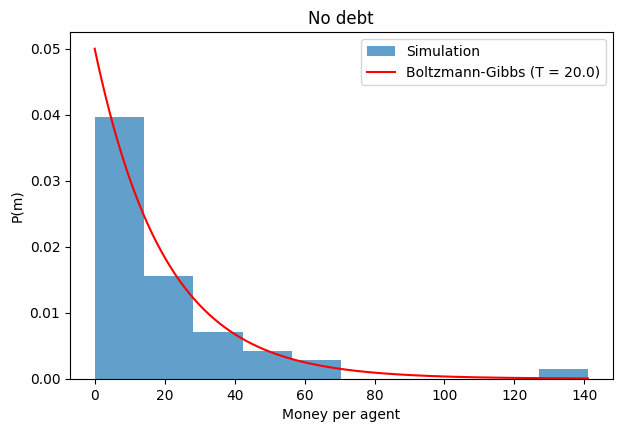

In [45]:
steps_dist = 200000  # about T^2 transactions per agent are needed to equilibrate
T = M / N

agents_no_debt = simulate_no_debt(N=N, M=M, steps=steps_dist, transaction_type='constant')

m = np.linspace(0, agents_no_debt.max(), 400)
plt.figure(figsize=(7, 4.5))
plt.hist(agents_no_debt, bins=10, density=True, alpha=0.7, label='Simulation')
plt.plot(m, np.exp(-m / T) / T, 'r', label=f'Boltzmann-Gibbs (T = {T:.1f})')
plt.xlabel('Money per agent')
plt.ylabel('P(m)')
plt.title('No debt')
plt.legend()
plt.show()

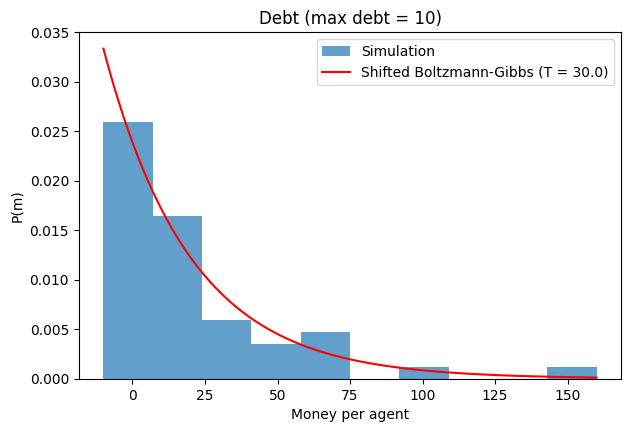

In [46]:
Td = md + M / N

agents_debt = simulate_with_debt(N=N, M=M, steps=steps_dist, md=md, transaction_type='constant')

m = np.linspace(-md, agents_debt.max(), 400)
plt.figure(figsize=(7, 4.5))
plt.hist(agents_debt, bins=10, density=True, alpha=0.7, label='Simulation')
plt.plot(m, np.exp(-(m + md) / Td) / Td, 'r', label=f'Shifted Boltzmann-Gibbs (T = {Td:.1f})')
plt.xlabel('Money per agent')
plt.ylabel('P(m)')
plt.title(f'Debt (max debt = {md})')
plt.legend()
plt.show()

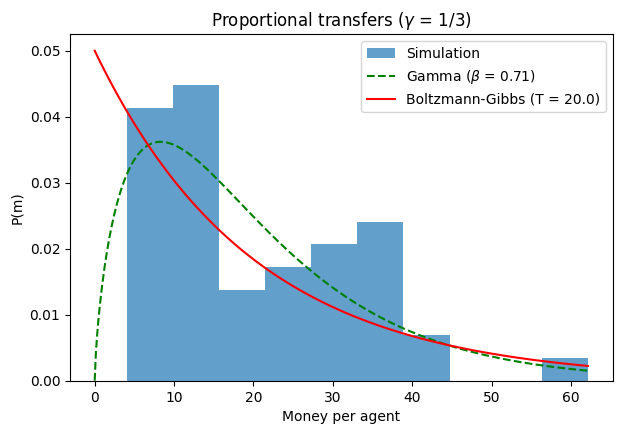

In [47]:
beta = -1 - np.log(2) / np.log(1 - gamma)
theta = M / (N * (beta + 1))  # the mean of the Gamma law is (beta + 1) * theta

agents_prop = simulate_proportional_money_transfer(N=N, M=M, steps=steps_dist, gamma=gamma)

m = np.linspace(1e-6, agents_prop.max(), 400)
gamma_pdf = m**beta * np.exp(-m / theta) / (theta**(beta + 1) * gamma_fn(beta + 1))
plt.figure(figsize=(7, 4.5))
plt.hist(agents_prop, bins=10, density=True, alpha=0.7, label='Simulation')
plt.plot(m, gamma_pdf, 'g--', label=rf'Gamma ($\beta$ = {beta:.2f})')
plt.plot(m, np.exp(-m / (M / N)) / (M / N), 'r', label=f'Boltzmann-Gibbs (T = {M/N:.1f})')
plt.xlabel('Money per agent')
plt.ylabel('P(m)')
plt.title(r'Proportional transfers ($\gamma$ = 1/3)')
plt.legend()
plt.show()